**Imports + load dataset**

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WineQT.csv")

**Basic dataset information**

In [52]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nQuality distribution:")
print(df["quality"].value_counts().sort_index())

Dataset shape: (1143, 13)

Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Quality distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


**Descriptive statistics**

In [53]:
print(df.describe().round(2))

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        1143.00           1143.00      1143.00         1143.00   
mean            8.31              0.53         0.27            2.53   
std             1.75              0.18         0.20            1.36   
min             4.60              0.12         0.00            0.90   
25%             7.10              0.39         0.09            1.90   
50%             7.90              0.52         0.25            2.20   
75%             9.10              0.64         0.42            2.60   
max            15.90              1.58         1.00           15.50   

       chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  \
count    1143.00              1143.00               1143.00  1143.00  1143.00   
mean        0.09                15.62                 45.91     1.00     3.31   
std         0.05                10.25                 32.78     0.00     0.16   
min         0.01                 1.0

**Correlation with quality**

In [54]:
correlation = df.corr(numeric_only=True)
print(correlation["quality"].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


**Correlation heatmap**

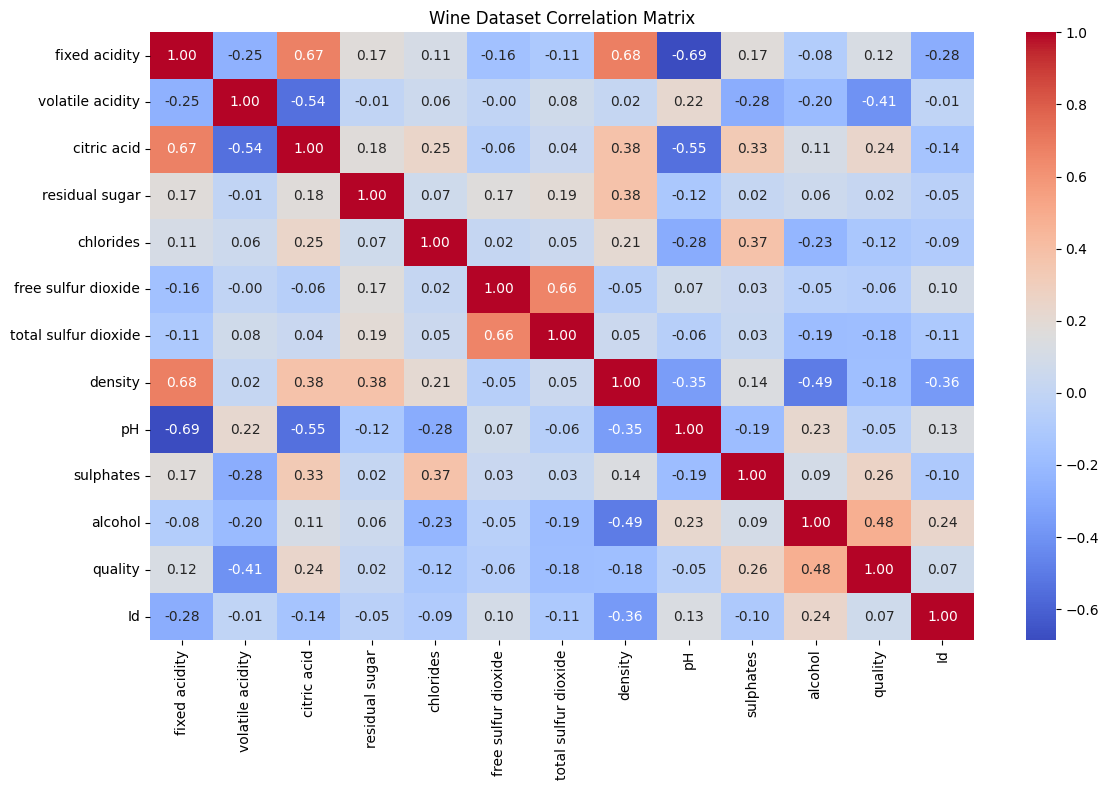

In [55]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Wine Dataset Correlation Matrix")
plt.tight_layout()
plt.show()

**Quality distribution graph**

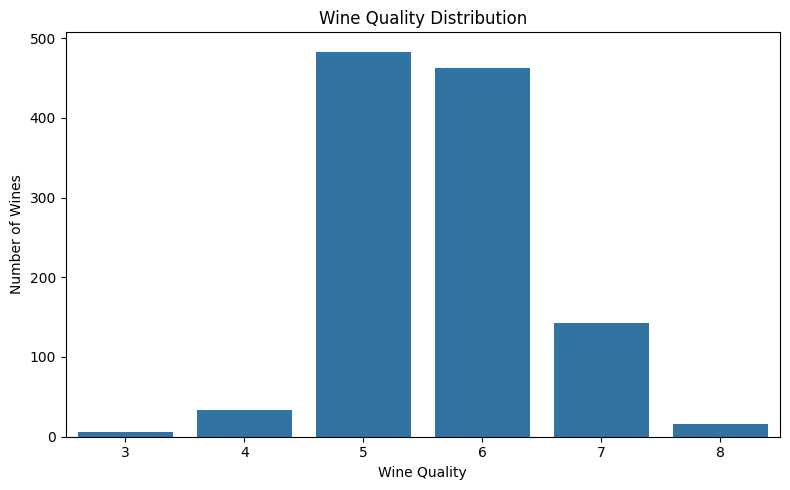

In [56]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Wine Quality Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")

plt.tight_layout()
plt.show()

**Use your reusable feature function**

In [57]:
from src.features import binarize_quality

df["quality_binary"] = binarize_quality(df)

print(df[["quality", "quality_binary"]].head(10))

print("\nValue counts:")
print(df["quality_binary"].value_counts().sort_index())

   quality  quality_binary
0        5               0
1        5               0
2        5               0
3        6               0
4        5               0
5        5               0
6        5               0
7        7               1
8        7               1
9        5               0

Value counts:
quality_binary
0    984
1    159
Name: count, dtype: int64
